# Train model

In [44]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model_asia2'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [45]:
filename = os.path.join(context['portfolio_dir'], hayai_util.FILE_FEATURES)
df = pd.read_parquet(filename)
df = df.replace([float('inf'), float('-inf')], float('nan'))
df = df.dropna()
df.shape

(251783, 64)

In [46]:
df.columns

Index(['000300.SS', '399001.SZ', 'AUDUSD', 'CL', 'CNYJPY', 'HG', 'NZDUSD',
       'SGDUSD', 'USDCNY', 'USDHKD', 'USDJPY', '^AXJO', '^GSPC', '^HSI',
       '^KS11', '^N225', '^NDX', '^STI', '^TWII', '^VIX', 'close_range',
       'country_China', 'country_Hong Kong', 'country_India', 'country_Japan',
       'country_Kazakhstan', 'country_Macau', 'country_Malaysia',
       'country_Philippines', 'country_Singapore', 'country_South Korea',
       'country_Taiwan', 'date', 'day_of_week', 'hl_range', 'log_return',
       'mom_10', 'mom_20', 'mom_5', 'mom_rank', 'mom_vol_adj',
       'sector_Basic Materials', 'sector_Consumer Discretionary',
       'sector_Consumer Staples', 'sector_Energy', 'sector_Finance',
       'sector_Health Care', 'sector_Industrials', 'sector_Miscellaneous',
       'sector_Real Estate', 'sector_Technology', 'sector_Telecommunications',
       'sector_Utilities', 'symbol', 'target', 'time_since_high', 'trend_50',
       'vol_10', 'vol_20', 'vol_ratio', 'vol_regime', 'v

## EDA

In [47]:
df.describe()

,000300.SS,399001.SZ,AUDUSD,CL,CNYJPY,HG,NZDUSD,SGDUSD,USDCNY,USDHKD,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,...,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000,251783.000000
mean,4030.187062,11276.498009,0.668828,75.960026,20.400580,4.371557,0.610531,0.749765,7.027516,7.810511,...,-0.110153,497.581477,-0.045471,0.084237,0.099896,0.875133,0.924477,1.036453,0.025205,-0.177328
std,451.475634,1740.493734,0.029914,12.553603,1.241368,0.616280,0.034809,0.019859,0.278087,0.027792,...,1.457007,340.560696,0.220954,0.076752,0.087172,0.280295,0.411967,1.208816,1.054071,1.265993
min,3159.250000,7964.709961,0.595529,55.270000,16.966467,3.210500,0.551849,0.695082,6.311500,7.751600,...,-5.000000,0.000000,-0.751977,0.001401,0.001758,0.227636,0.168764,0.000000,-1.444365,-2.630236
25%,3733.239990,10052.089844,0.649480,67.580002,19.675097,3.874500,0.588400,0.737768,6.911000,7.784860,...,-0.801927,207.000000,-0.147766,0.037750,0.047731,0.669533,0.633146,0.404355,-0.604181,-1.160557
50%,3957.780029,10996.410156,0.662730,74.070000,20.474077,4.299000,0.604379,0.745218,7.126600,7.810500,...,-0.115371,442.000000,-0.037877,0.062170,0.076192,0.892168,0.866146,0.740366,-0.284724,-0.352410
75%,4343.879883,12473.169922,0.681301,81.800003,21.202177,4.683000,0.623069,0.767154,7.228800,7.836780,...,0.554579,764.000000,0.049660,0.102170,0.119989,1.096942,1.152945,1.187632,0.301173,0.774908
max,5083.799805,15212.490234,0.758570,123.699997,23.249290,6.175500,0.719870,0.793210,7.350000,7.850500,...,5.000000,1249.000000,0.759662,0.482714,0.557106,1.387627,2.205683,8.394452,3.997162,2.903524


In [48]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 251783 entries, 60 to 357286
Data columns (total 62 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   000300.SS                      251783 non-null  float64
 1   399001.SZ                      251783 non-null  float64
 2   AUDUSD                         251783 non-null  float64
 3   CL                             251783 non-null  float64
 4   CNYJPY                         251783 non-null  float64
 5   HG                             251783 non-null  float64
 6   NZDUSD                         251783 non-null  float64
 7   SGDUSD                         251783 non-null  float64
 8   USDCNY                         251783 non-null  float64
 9   USDHKD                         251783 non-null  float64
 10  USDJPY                         251783 non-null  float64
 11  ^AXJO                          251783 non-null  float64
 12  ^GSPC                          251783 non-nul

In [49]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

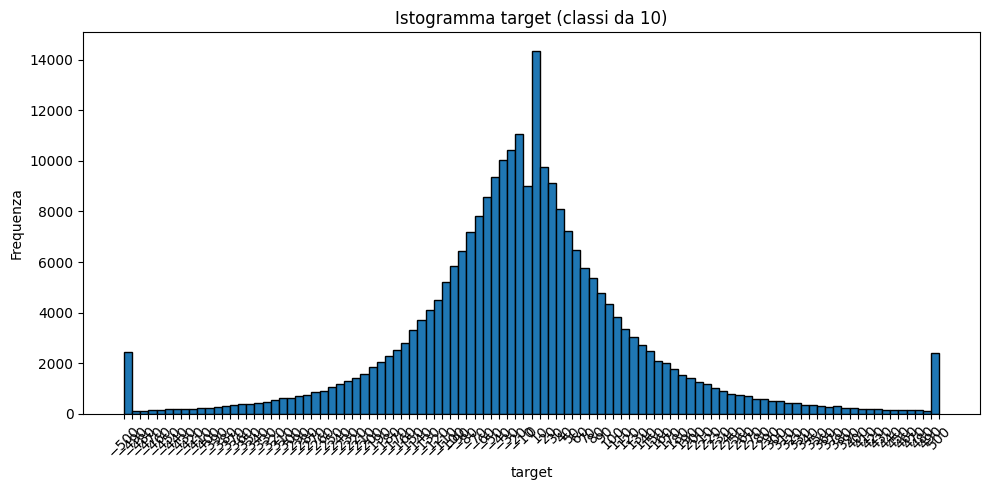

In [50]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

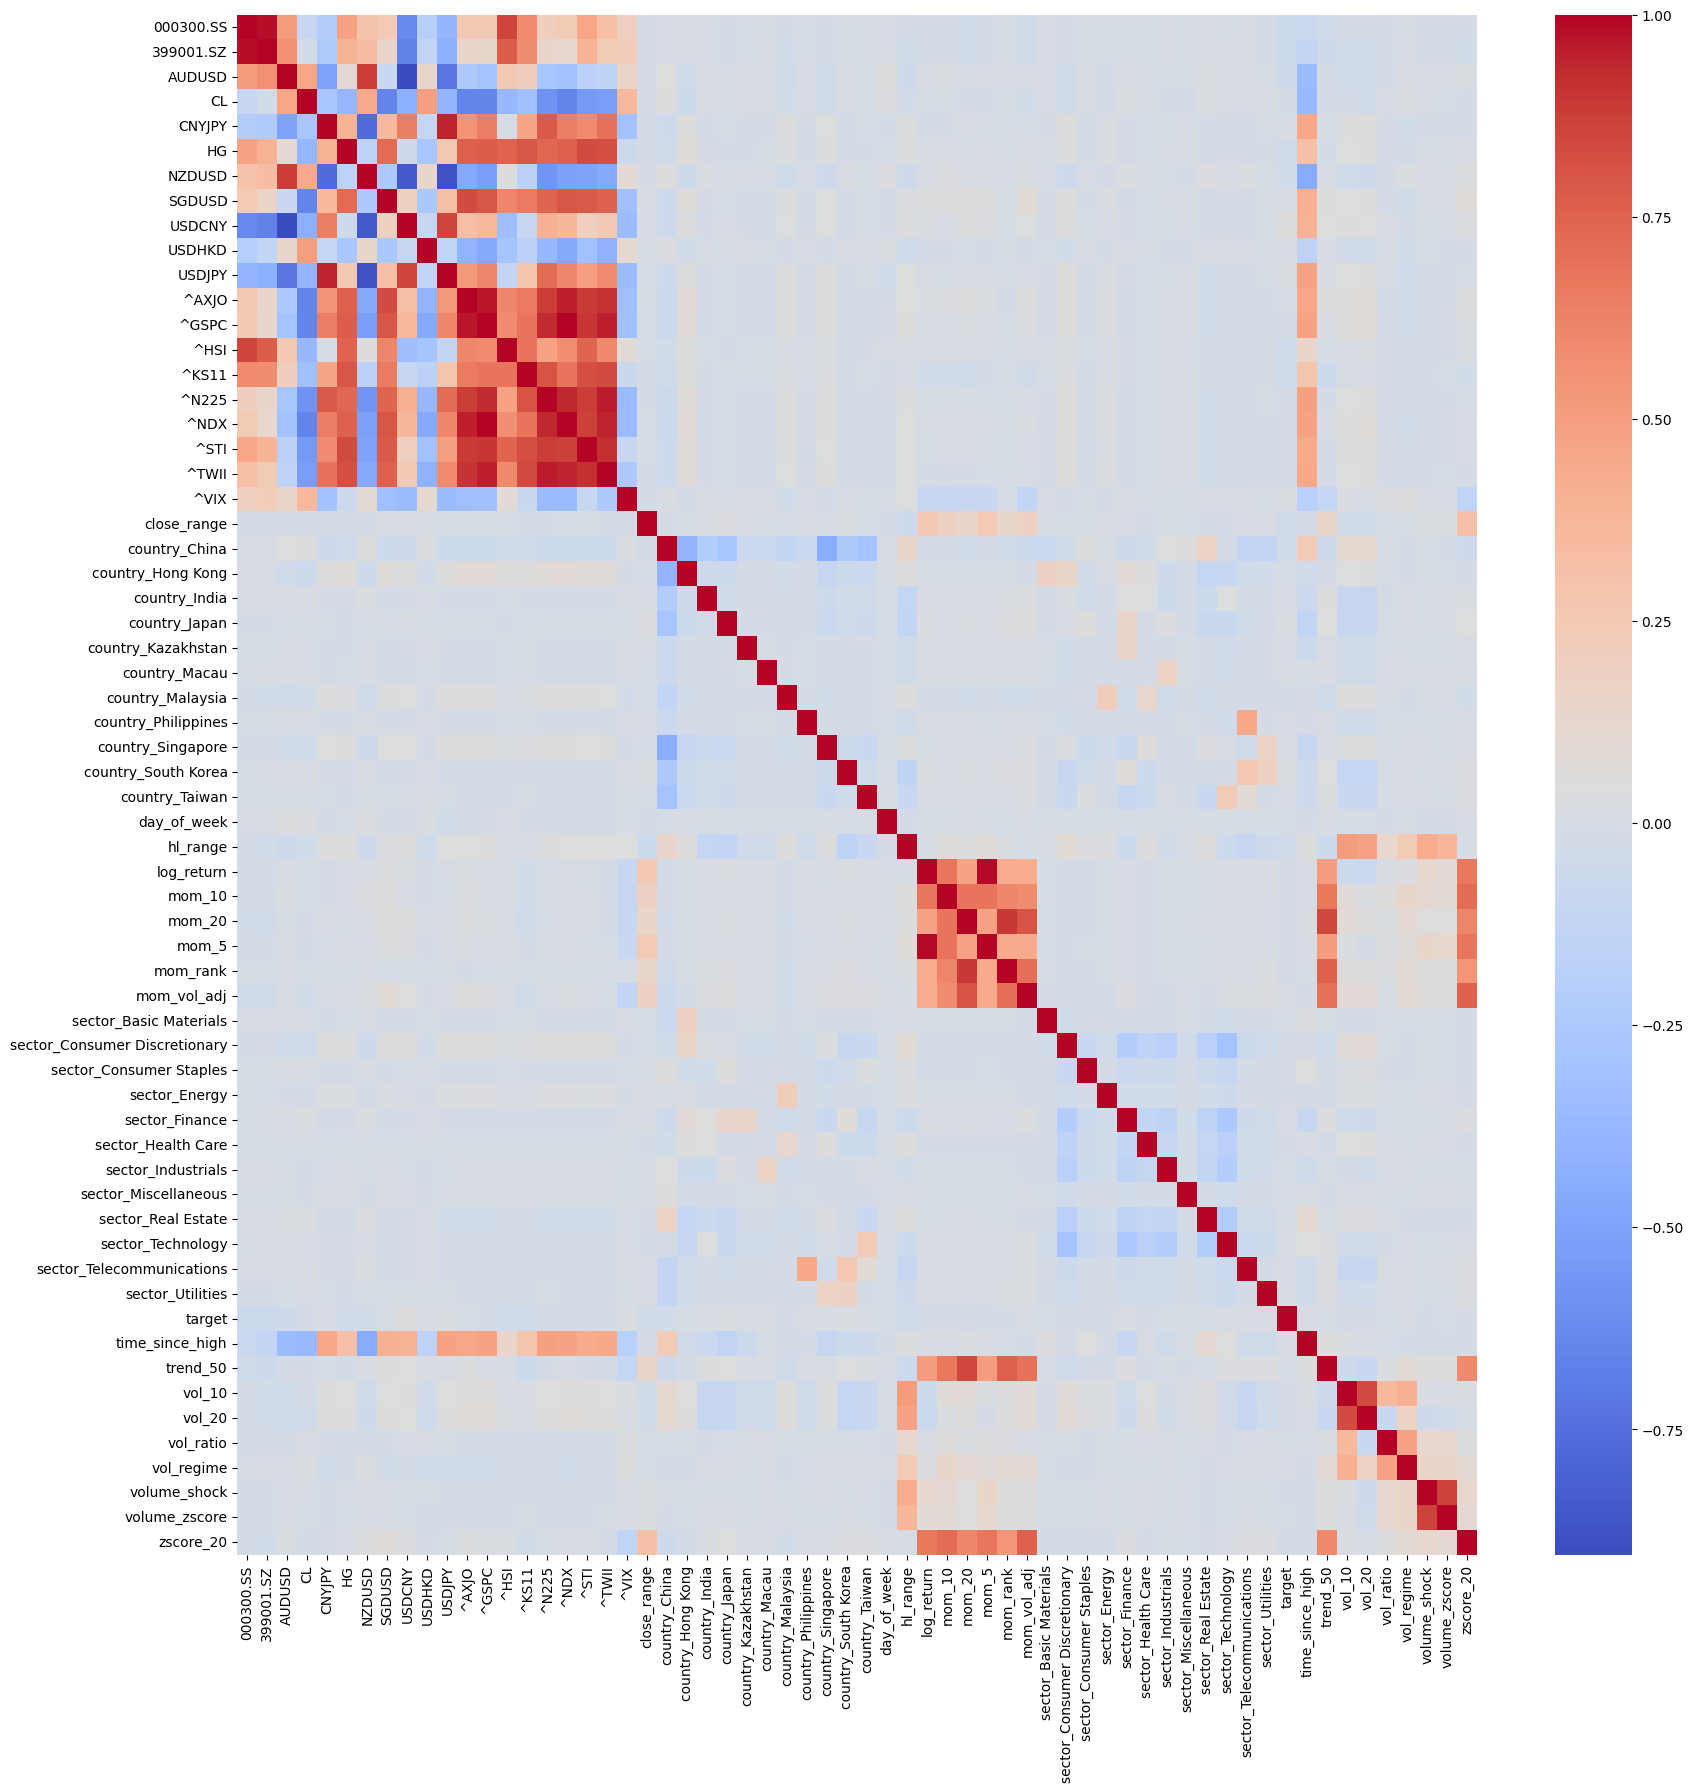

In [51]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [52]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

In [53]:
# check for +inf or -inf in mins and maxs, thrown an exception if found
if maxs.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in maxs")
if mins.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in mins")

## Model building

In [54]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [55]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (251783,)
Data Shape: (251783, 61)
Train Data Shape: (201426, 61)
Train Labels Shape: (201426,)
Test Data Shape: (50357, 61)
Test Labels Shape: (50357,)


In [56]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         6,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,921 (62.19 KB)

 Trainable params: 15,921 (62.19 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
2518/2518 - 4s - 1ms/step - loss: 0.0210 - val_loss: 0.0210
Epoch 2/30
2518/2518 - 3s - 1ms/step - loss: 0.0207 - val_loss: 0.0206
Epoch 3/30
2518/2518 - 3s - 1ms/step - loss: 0.0205 - val_loss: 0.0205
Epoch 4/30
2518/2518 - 2s - 946us/step - loss: 0.0202 - val_loss: 0.0203
Epoch 5/30
2518/2518 - 2s - 982us/step - loss: 0.0200 - val_loss: 0.0202
Epoch 6/30
2518/2518 - 2s - 926us/step - loss: 0.0198 - val_loss: 0.0200
Epoch 7/30
2518/2518 - 2s - 982us/step - loss: 0.0197 - val_loss: 0.0199
Epoch 8/30
2518/2518 - 3s - 1ms/step - loss: 0.0196 - val_loss: 0.0199
Epoch 9/30
2518/2518 - 3s - 1ms/step - loss: 0.0194 - val_loss: 0.0198
Epoch 10/30
2518/2518 - 2s - 972us/step - loss: 0.0193 - val_loss: 0.0198
Epoch 11/30
2518/2518 - 2s - 954us/step - loss: 0.0192 - val_loss: 0.0197
Epoch 12/30
2518/2518 - 3s - 1ms/step - loss: 0.0190 - val_loss: 0.0197
Epoch 13/30
2518/2518 - 2s - 953us/step - loss: 0.0189 - val_loss: 0.0197
Epoch 14/30
2518/2518 - 2s - 988us/step - loss: 0.0188 - va

Model saved to: data\model_asia2\model.keras


In [58]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.01442202 0.97192574
Label: 0.3120, Prediction: 0.1387
Label: -0.7710, Prediction: -1.4319
Label: 0.6976, Prediction: 0.2824
Label: -1.2116, Prediction: -0.2933
Label: -1.1606, Prediction: -0.0254
Label: -0.7539, Prediction: 0.0775
Label: -0.0641, Prediction: 0.1231
Label: -0.8408, Prediction: -0.5462
Label: -0.8658, Prediction: -0.0187
Label: 0.3259, Prediction: -0.0187
Label: 0.2112, Prediction: 0.2828
Label: -0.5333, Prediction: 0.0074
Label: 0.4725, Prediction: 0.6477
Label: -2.3229, Prediction: -0.0177
Label: -2.1951, Prediction: -0.2059
Label: -0.7580, Prediction: -0.6148
Label: -0.4786, Prediction: 0.0165
Label: 0.2052, Prediction: -0.1127
Label: -0.1279, Prediction: -0.0187
Label: 0.0658, Prediction: -0.4211
Label: 1.1131, Prediction: 0.3209
Label: 0.9480, Prediction: 0.8123
Label: 2.4775, Prediction: -2.3612
Label: -0.8625, Prediction: 0.1930
Label: 1.3713, Prediction: 0.1042
Label: -0.5623, Prediction: -0.3452
Label: 2.0669, Prediction: 0.0214
Lab